# Intro

**Problem**- I get the following error when I run my simulations: `LibraryError: The simulation model supplied resulted in a parent node having a time value <= to its child. This can occur either as a result of multiple bottlenecks happening at the same time or because of numerical imprecision with very small population sizes.`  

The simulation steps are as follows:
1. convert species distribution model predictions to a local deme size matrix (the input matrix has values ranging from 0-1 and the output is all positive integers or zero).
2. create a 2D stepping stone model (msprime Demography object) by converting the local deme size matrix to a metapopulation connected by a constant migration rate
3. add discrete population size changes to the original 2D stepping stone model according to time-specific local deme size matrices
4. merge all of the demes in the metapopulation into a single population at a specific time point in the past
5. select two individuals from each deme that has at least two individuals in the most recent time step and run coalescent simulations with msprime.sim_ancestry().

I think the error is due to numerical imprecision with very small population sizes (some populations go extinct often or remain at low or zero population size the entire simulation), but I've failed to create a minimal reproducible example that duplicates the error. My attempt to create a minimal reproducible example (section **Attempt to create a minimal reproducible example**) suggests that small population sizes may not be the problem, but I also don't think I'm accidentally assigning multiple bottlenecks happening at the same time. So, I'm not sure what is causing the error.  

I apologize for the amount of code, but hopefully it's not too onerous to parse. This notebook is separated into three sections: the functions I use for the simulations (**Functions**), model testing for the full model (**Full model**), and my attempt to create a minimum reproducible example (**Attempt to create a minimum reproducible example**). 


# Functions
These are the functions I'm using to conduct simulations and are relevant to the present error.

- `raster_to_k()`- convert species distribution model predictions to a local deme size/carrying capacity matrix
- `stepping_stone2d()`- convert a local deme size matrix and migration rate (single value or matrix) into an msprime Demography object
- `add_landscape_change()`- add discrete population size changes to the original 2D stepping stone model according to species distribution models projected to time periods in the past
- `add_nonspatial_phase()`- collapse the metapopulation into a single population at a certain time point in the past


## Function to convert raster stack to K values

I'm writing a function to convert a single raster or multiple rasters to local carrying capacities (K) with the possibility of a linear, hinge, or sigmoid transformation

This is a basic function to transform a raster to local carrying capacity (K) values. This function was created with the idea of taking in presence probability/habitat suitability rasters scaled from 0 to 1, where 0 is no suitability and 1 is the highest suitability. However, it is flexible enough to accomodate other continuous rasters that can be coaxed to a 0 to 1 scale with the operation `(data - np.min(data)) / (np.max(data) - np.min(data))` by setting the `normalize` flag to `True`. 
- The "linear" transformation multiplies the input (raw or transformed) values by the maximum local carrying capacity (max_local_k).
- The "hinge" transformation creates a raster where values below the `threshold` value are set to zero and values about the `threshold` value are set to 1. Note, this transformation is applied *after* normalizing if the `normalize` flag is set to `True`.
- The "sigmoid" transformation applies a sigmoid function to the data using Eq. 1 from [Frazier and Wang 2013, Modeling landscape structure response across a gradient of land cover intensity](https://www.researchgate.net/publication/257319938_Modeling_landscape_structure_response_across_a_gradient_of_land_cover_intensity), where an `inflection_point` and `slope` are specified. The `inflection_point` can be thought of like a `threshold` value, where original values below this value descend quicker to zero, and values about this value increase quicker to 1. The slope determines how fast values change on either side of the inflection point. A sufficiently steep slope makes this a hinge function, while a sufficiently shallow slope makes this a linear function.

In [27]:
import numpy as np
def raster_to_k(raster, transformation = "linear", max_local_k = 100, normalize = False, threshold = None, inflection_point = 0.5, slope = 0.05):

    d = raster.filled(0)

    if normalize:
        def normalize(rast):
            return (rast - np.min(rast)) / (np.max(rast) - np.min(rast))
        
        d = normalize(d)
    
    if transformation == "linear":
        t = d * max_local_k
        t = np.ceil(t)

    if transformation == "hinge":
        t = d
        t[t >= threshold] = max_local_k
        t[t < threshold] = 0

    if transformation == "sigmoid":
        def sigmoid(x, a, b):
            y = 1.0 / (1.0 + np.ma.exp(-(x - a) / b))
            return(y)
        
        sigmoid_v = np.vectorize(sigmoid)
        t = sigmoid_v(d, inflection_point, slope) * max_local_k
        t = np.ceil(t)
    

    return(t.astype(int))
    
  

## 2D Stepping Stone model

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I'm importing Jerome Kelleher's version of the 2D stepping stone model to work with. 
`initial_size` is the local population size for each deme in the model
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.


In [2]:
import msprime
import numpy as np

def stepping_stone2d(initial_size, rate):
    assert len(initial_size.shape) <= 3

    n, m = initial_size.shape
    N = n * m
    model = msprime.Demography.isolated_model(initial_size.reshape(N))

    if np.array(rate).ndim == 0:
        M = model.migration_matrix
        for j in range(n):
            for k in range(m):
                index = j * m + k
                model.populations[index].name = f"pop_{j}_{k}"
                M[index, index - 1] = rate
                M[index, (index + 1) % N] = rate
                M[index, index - m] = rate
                M[index, (index + m) % N] = rate

                M[index - 1, index] = rate
                M[(index + 1) % N, index] = rate
                M[index - m, index] = rate
                M[(index + m) % N, index] = rate
    else:
        assert rate.shape == (N, N), f"Expected a migration matrix with the shape {(N, N)} and instead got {rate.shape}"
        model.migration_matrix = rate

    
    return model


## Add demographic changes based on landscape change to 2D stepping stone model

The `model` is an `msprime.Demography` object that needs to be initialized using `stepping_stone_2d()`.  
`k_stack` is a 3D numpy array of the local carrying capacities across the landscape for each timestep except the most current timestep.  
`timestep` is the amount of time that passes between each landscape change, measured in generations. For instance, if each landscape is 100 years apart and the generation time of the organism is 1 year, `timestep` is 100. However, if the generation time of the organism is 2 years, `timestep` is 50. 


In [3]:
import msprime
import numpy as np
def add_landscape_change(model, k_stack, timestep = 1):
    # iterate through each raster in the raster stack, skipping the first
    for step in range(1, k_stack.shape[0]):
        # get the k values of the raster
        kmat = k_stack[step]
        # get the shape of the raster
        n, m = kmat.shape
        # iterate through each value in the raster
        for j in range(n):
            for k in range(m):
                # add a demographic change to each cell in the raster
                model.add_population_parameters_change(time=step * timestep, population=f"pop_{j}_{k}", initial_size=kmat[j, k])
                
    
    return model


## Add nonspatial phase to 2D stepping stone model

`ancestral_size` is the size of the ancestral population that all demes coalesce to. 

`merge_time` is the time in generations that the metapopulation merges into the ancestral population(s)

In [4]:
import msprime
import numpy as np

def add_nonspatial_phase(model, ancestral_size, merge_time):
    # add an ancestral population
    model.add_population(name = "ANC", initial_size=ancestral_size)

    # get names of populations for initiating the collecting phase
    pop_names = [[pop.name] for pop in model.populations if pop.name != "ANC"]

    # add the time when the spatial simulation collapses into the collecting phase
    [model.add_population_split(time = merge_time, derived = name, ancestral = "ANC") for name in pop_names]

    return model

# Model testing

## Full model
This is the empirical model that reproduces the error. The only thing that needs changed is the file path to the sdm_projections_ihe_10km.tif file.  

Note- the model is huge, so printing the Demography object or running the demography debugger takes an eternity (I've tried to wait it out, but lost patience after 20 minutes). Print at your own risk.  

Read in the multiband raster. Specify the path to be where you downloaded the sdm_projections_ihe_10km.tif file.

In [28]:
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 110, 'height': 117, 'count': 21, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0833333329997884, 0.0, -52.35847273325492,
       0.0, -0.08333333300085433, -21.508472496174495), 'blockysize': 1, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}


In [29]:
# make sure everything is read in correctly. Shape should be (21, 117, 110)
r.shape

(21, 117, 110)

Convert the rasters to local deme sizes, with a maximum size of 100 (I've explored values between 100 and 1000).

In [161]:
k = raster_to_k(r, transformation="linear", max_local_k = 100)

k.shape

(21, 117, 110)

In [212]:
import numpy as np

def get_centered_subsets(arr, sizes):
    # calculate the center of the array
    center = np.array(arr.shape[1:3]) // 2

    subsets = []
    for size in sizes:
        # calculate the starting and ending indices for the subset
        start_indices = center - size // 2
        # don't allow start_indices to go below zero
        if start_indices[0] < 0:
            start_indices[0] = 0
        if start_indices[1] < 0:
            start_indices[1] = 0

        end_indices = start_indices + size
        # don't allow end indices to go beyond the smallest dimension
        if end_indices[0] > 110:
            end_indices[0] = 110
        if end_indices[1] > 110:
            end_indices[1] = 110


        # create the subset using numpy's array slicing
        subset = arr[:, start_indices[0]:end_indices[0], start_indices[1]:end_indices[1]]
        subsets.append(subset)

    return subsets



In [244]:
ks = k[:, 0:116, 0:110]

ks[0].shape



(117, 110)

Check the first raster to see if the conversion didn't introduce weird artifacts. There should be blue along the east coast, expanding to the north, and red in the south, disappearing at 20° latitude.

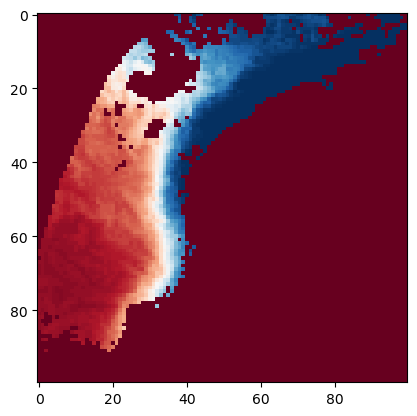

In [234]:
from matplotlib import pyplot

pyplot.imshow(k[0]], cmap='RdBu')

pyplot.show() 

Parameterize a 2D stepping stone model in msprime using the first raster timestep. Output is a Demography object. Although it's tempting, DO NOT print this or use the demography debugger. It will run for eternity trying to print all of the information for thousands of demes and many thousands migration edges.

In [245]:
m = stepping_stone2d(k[0], rate = 0.0001)

Add population size changes to all demes in the 2D stepping stone model, specifying the difference in time (in generations).  
Takes ~1m 20s on a MacBook Air.

In [246]:
m = add_landscape_change(model = m, k_stack = k, timestep = 1000)

Add time which the populations merge into a nonspatial single population. The size here is approximately the size of all of the demes added together when the maximum deme size is 100.

In [247]:
m = add_nonspatial_phase(m, ancestral_size=20000, merge_time=21000)

I run sort_events just to make sure everything is happening in order.

In [248]:
m.sort_events()

In [ ]:
m

Sample 2 individuals from every present-day deme that has at least two individuals and run the simulation with a genome size that is 1e7 and low recombination rate (1e-9).

This is where the error pops up, after ~ 3m.

In [249]:
# find all present-day populations with at least two individuals
nzp = []
for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
        nzp.append(m.populations[i].name)
    # set the default sampling time to the present
    m.populations[i].default_sampling_time = 0

# sample 2 individuals from each population
pop_dict = {key: 2 for key in nzp}

ts = msprime.sim_ancestry(pop_dict, sequence_length=1e7, demography = m, recombination_rate=1e-9, record_provenance=False)

In [250]:
ts

## Attempt to create a minimum reproducible example

The only reason I can think of to be getting the above error is because of numerical imprecision with low population sizes. I've double-checked my code and cannot find a place where I mispecified the demography to include multiple bottlenecks happening at the same time point.  

The below code builds a smaller model (10 x 10 deme matrix) with very small population sizes, where each size is chosen from a poisson distribution with a 1.0 lambda parameter. Additionally, I made two specifications that I thought may throw an error: 
1. specifying populations along the rightmost edge to remain empty the entire simulation
2. including a timestep with all zero population sizes

Nothing seems to throw it off.

In [29]:
import numpy as np

np.random.seed(1234)
rng = np.random.default_rng()
k = np.zeros([20, 10, 10], np.int8)

z, n, m = k.shape

for z in range(z - 1):
    for x in range(n):
        for y in range(m - 1):
           k[z, x, y] = np.random.poisson(1.0, 1)[0]


k



array([[[0, 1, 2, ..., 1, 0, 0],
        [2, 1, 1, ..., 2, 3, 0],
        [0, 0, 2, ..., 0, 5, 0],
        ...,
        [0, 0, 1, ..., 1, 1, 0],
        [2, 0, 4, ..., 0, 1, 0],
        [1, 3, 2, ..., 1, 0, 0]],

       [[1, 1, 0, ..., 0, 2, 0],
        [1, 1, 2, ..., 0, 1, 0],
        [3, 0, 1, ..., 0, 0, 0],
        ...,
        [1, 0, 0, ..., 2, 4, 0],
        [2, 1, 0, ..., 0, 0, 0],
        [2, 2, 2, ..., 0, 2, 0]],

       [[1, 2, 1, ..., 2, 0, 0],
        [2, 0, 1, ..., 2, 1, 0],
        [2, 1, 1, ..., 1, 1, 0],
        ...,
        [0, 0, 1, ..., 2, 0, 0],
        [1, 0, 2, ..., 1, 2, 0],
        [0, 2, 0, ..., 1, 0, 0]],

       ...,

       [[1, 0, 1, ..., 1, 1, 0],
        [1, 0, 0, ..., 1, 0, 0],
        [3, 0, 0, ..., 0, 1, 0],
        ...,
        [2, 1, 0, ..., 3, 0, 0],
        [0, 0, 2, ..., 2, 1, 0],
        [3, 2, 2, ..., 1, 0, 0]],

       [[1, 1, 0, ..., 0, 1, 0],
        [1, 2, 1, ..., 0, 2, 0],
        [0, 1, 1, ..., 2, 3, 0],
        ...,
        [4, 0, 2, ..., 

In [30]:

m = stepping_stone2d(k[0], rate = 0.001)

m = add_landscape_change(model = m, k_stack = k, timestep = 1000)

m = add_nonspatial_phase(m, ancestral_size=100, merge_time=21000)

m.sort_events()

# get populations with at least two individuals to sample for coalescent simulations
nzp = []
for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
        nzp.append(m.populations[i].name)

pop_dict = {key: 2 for key in nzp}

ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=1e-9, record_provenance=False)

ts = msprime.sim_mutations(ts, rate = 1e-7)

In [31]:
ts